# 00 - FITS como tensor: matriz 10x10 y perfil z

Objetivo: enseñar con una captura pequeña que el cubo FITS se indexa como `cube[z, y, x]` y que cada celda contiene una intensidad `float`.

En este notebook todo corresponde al mismo punto elegido:

- **A)** matriz 10x10 en el plano `z_selected`.
- **B)** la misma matriz 10x10 con los valores escritos.
- **C)** perfil en `z` del píxel espacial seleccionado `(y_selected, x_selected)`.

Así queda clara la correspondencia: A y B usan el mismo `z`, y C usa el mismo `y,x` recorriendo solo 10 canales alrededor de ese `z`.


In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.io.fits.verify import VerifyWarning
from astropy.wcs import WCS, FITSFixedWarning

warnings.simplefilter("ignore", VerifyWarning)
warnings.simplefilter("ignore", FITSFixedWarning)


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "sky_dev_v2.fits").exists():
            return candidate
    raise FileNotFoundError("No se ha encontrado data/sky_dev_v2.fits. Ajusta FITS_PATH.")


PROJECT_ROOT = find_project_root()
STEP_ROOT = PROJECT_ROOT / "demo" / "paso1"
TABLES_DIR = STEP_ROOT / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(STEP_ROOT / ".matplotlib"))
(STEP_ROOT / ".matplotlib").mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

FITS_PATH = PROJECT_ROOT / "data" / "sky_dev_v2.fits"
TRUTH_PATH = PROJECT_ROOT / "data" / "sky_dev_truthcat_v2.txt"

FIGURES_DIR = STEP_ROOT / "figures" / "00_tensor_pixel"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"FIGURES_DIR: {FIGURES_DIR}")
print(f"TABLES_DIR: {TABLES_DIR}")


FIGURES_DIR: /home/willy/sdc2/demo/paso1/figures/00_tensor_pixel
TABLES_DIR: /home/willy/sdc2/demo/paso1/tables


In [2]:
def require_file(path: Path, label: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"No se ha encontrado {path}. Ajusta {label}.")
    return path


def open_fits_cube(path: Path):
    """Abre el FITS con memmap=True. No carga el cubo entero en RAM."""
    require_file(path, "FITS_PATH")
    hdul = fits.open(path, memmap=True)
    hdu = next((item for item in hdul if item.data is not None), None)
    if hdu is None:
        hdul.close()
        raise ValueError(f"El FITS no contiene datos: {path}")
    data = np.squeeze(hdu.data)
    if data.ndim != 3:
        hdul.close()
        raise ValueError(f"Se esperaba un cubo 3D tras squeeze(), pero shape={data.shape}")
    return hdul, data, hdu.header


def percentile_limits(values, low=5, high=95):
    finite = np.asarray(values)[np.isfinite(values)]
    if finite.size == 0:
        return None, None
    vmin, vmax = np.nanpercentile(finite, [low, high])
    if np.isclose(vmin, vmax):
        return None, None
    return float(vmin), float(vmax)


def centered_start(center: int, size: int, max_size: int) -> int:
    return int(np.clip(center - size // 2, 0, max_size - size))


def save_figure(fig, path: Path, dpi=160):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"Figura guardada: {path}")


def matrix_dataframe(matrix, y0_global, x0_global):
    return pd.DataFrame(
        [[f"{float(matrix[i, j]):.3e}" for j in range(matrix.shape[1])] for i in range(matrix.shape[0])],
        index=[f"y={y0_global + i}" for i in range(matrix.shape[0])],
        columns=[f"x={x0_global + j}" for j in range(matrix.shape[1])],
    )


def plot_a_patch(matrix10, selected_local_y, selected_local_x, selected_global_zyx, selected_value, output_path, title):
    vmin, vmax = percentile_limits(matrix10, 5, 95)
    fig, ax = plt.subplots(figsize=(4.2, 4.0), facecolor="white")
    ax.imshow(matrix10, origin="lower", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.scatter([selected_local_x], [selected_local_y], c="black", marker="x", s=55, linewidths=1.8)
    ax.set_title(title)
    ax.set_xlabel("x local")
    ax.set_ylabel("y local")
    z, y, x = selected_global_zyx
    ax.text(
        0.03, 0.97,
        f"pixel elegido\nz,y,x=({z},{y},{x})\nI={selected_value:.2e}",
        transform=ax.transAxes, va="top", ha="left", fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.78, "pad": 3},
    )
    save_figure(fig, output_path)
    plt.show()


def plot_b_values(matrix10, selected_local_y, selected_local_x, output_path, title):
    vmin, vmax = percentile_limits(matrix10, 5, 95)
    threshold = np.nanmean(matrix10)
    fig, ax = plt.subplots(figsize=(5.2, 5.0), facecolor="white")
    ax.imshow(matrix10, origin="lower", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("x local")
    ax.set_ylabel("y local")
    ax.set_xticks(np.arange(matrix10.shape[1]))
    ax.set_yticks(np.arange(matrix10.shape[0]))
    ax.tick_params(labelsize=7)
    for local_y in range(matrix10.shape[0]):
        for local_x in range(matrix10.shape[1]):
            value = float(matrix10[local_y, local_x])
            color = "white" if value < threshold else "black"
            ax.text(local_x, local_y, f"{value:.1e}", ha="center", va="center", fontsize=5.5, color=color)
    ax.scatter([selected_local_x], [selected_local_y], edgecolors="red", facecolors="none", marker="o", s=80, linewidths=1.5)
    save_figure(fig, output_path)
    plt.show()


def plot_c_profile(z_values, profile, z_selected, selected_global_yx, output_path, title):
    fig, ax = plt.subplots(figsize=(5.4, 2.9), facecolor="white")
    ax.plot(z_values, profile, color="black", lw=1.3, marker="o", markersize=3)
    ax.axvline(z_selected, color="0.35", lw=1.0, linestyle="--")
    y, x = selected_global_yx
    ax.set_title(title)
    ax.set_xlabel("z")
    ax.set_ylabel("intensidad")
    ax.grid(alpha=0.22, color="0.7")
    ax.text(
        0.03, 0.95,
        f"pixel fijo: y={y}, x={x}\nz central={z_selected}",
        transform=ax.transAxes, va="top", ha="left", fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.75, "pad": 3},
    )
    save_figure(fig, output_path)
    plt.show()


def plot_summary(matrix10, selected_local_y, selected_local_x, z_values, profile, z_selected, output_path, title):
    vmin, vmax = percentile_limits(matrix10, 5, 95)
    threshold = np.nanmean(matrix10)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), facecolor="white")

    axes[0].imshow(matrix10, origin="lower", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    axes[0].scatter([selected_local_x], [selected_local_y], c="black", marker="x", s=45, linewidths=1.6)
    axes[0].set_title("A) matriz 10x10")
    axes[0].set_xlabel("x local")
    axes[0].set_ylabel("y local")

    axes[1].imshow(matrix10, origin="lower", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    axes[1].set_title("B) valores")
    axes[1].set_xticks(np.arange(matrix10.shape[1]))
    axes[1].set_yticks(np.arange(matrix10.shape[0]))
    axes[1].tick_params(labelsize=6)
    for local_y in range(matrix10.shape[0]):
        for local_x in range(matrix10.shape[1]):
            value = float(matrix10[local_y, local_x])
            color = "white" if value < threshold else "black"
            axes[1].text(local_x, local_y, f"{value:.1e}", ha="center", va="center", fontsize=4.8, color=color)
    axes[1].scatter([selected_local_x], [selected_local_y], edgecolors="red", facecolors="none", marker="o", s=65, linewidths=1.3)

    axes[2].plot(z_values, profile, color="black", lw=1.3, marker="o", markersize=3)
    axes[2].axvline(z_selected, color="0.35", lw=1.0, linestyle="--")
    axes[2].set_title("C) perfil z")
    axes[2].set_xlabel("z")
    axes[2].set_ylabel("intensidad")
    axes[2].grid(alpha=0.22, color="0.7")

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    save_figure(fig, output_path)
    plt.show()


## Selección del punto

Por defecto usamos el centro del cubo. Puedes cambiar `Z_SELECTED`, `Y_SELECTED` o `X_SELECTED` para apuntar a otro voxel.

Solo se leen:

- una matriz 10x10 en `z_selected`,
- un perfil de 10 canales en el punto `(y_selected, x_selected)`.


In [3]:
hdul, data, header = open_fits_cube(FITS_PATH)
print(f"shape: {data.shape}")
print(f"dtype: {data.dtype}")
print(f"tamaño lógico estimado: {data.size * data.dtype.itemsize / 1024**3:.2f} GB")

MATRIX_SIZE = 10
Z_PROFILE_SIZE = 10

Z_SELECTED = data.shape[0] // 2
Y_SELECTED = data.shape[1] // 2
X_SELECTED = data.shape[2] // 2

z_selected = int(np.clip(Z_SELECTED, 0, data.shape[0] - 1))
y_selected = int(np.clip(Y_SELECTED, 0, data.shape[1] - 1))
x_selected = int(np.clip(X_SELECTED, 0, data.shape[2] - 1))

matrix_y0 = centered_start(y_selected, MATRIX_SIZE, data.shape[1])
matrix_x0 = centered_start(x_selected, MATRIX_SIZE, data.shape[2])
matrix10 = np.asarray(data[z_selected, matrix_y0:matrix_y0 + MATRIX_SIZE, matrix_x0:matrix_x0 + MATRIX_SIZE], dtype=np.float32)

local_y = y_selected - matrix_y0
local_x = x_selected - matrix_x0
selected_value = float(data[z_selected, y_selected, x_selected])

z_start = centered_start(z_selected, Z_PROFILE_SIZE, data.shape[0])
z_stop = z_start + Z_PROFILE_SIZE
z_values = np.arange(z_start, z_stop)
profile10 = np.asarray(data[z_start:z_stop, y_selected, x_selected], dtype=np.float32)

print(f"Voxel elegido global z,y,x = ({z_selected}, {y_selected}, {x_selected})")
print(f"Valor elegido = {selected_value:.8g}")
print(f"Matriz A/B: cube[{z_selected}, {matrix_y0}:{matrix_y0 + MATRIX_SIZE}, {matrix_x0}:{matrix_x0 + MATRIX_SIZE}]")
print(f"Perfil C: cube[{z_start}:{z_stop}, {y_selected}, {x_selected}]")
print(f"Coordenada local del punto en la matriz: y={local_y}, x={local_x}")


shape: (6668, 643, 643)
dtype: >f4
tamaño lógico estimado: 10.27 GB
Voxel elegido global z,y,x = (3334, 321, 321)
Valor elegido = -4.5611785e-05
Matriz A/B: cube[3334, 316:326, 316:326]
Perfil C: cube[3329:3339, 321, 321]
Coordenada local del punto en la matriz: y=5, x=5


## A) Matriz 10x10

Esta imagen es un slice pequeño del plano `z_selected`. El punto negro marca el voxel seleccionado.


Figura guardada: /home/willy/sdc2/demo/paso1/figures/00_tensor_pixel/A_matrix_10x10_gray.png


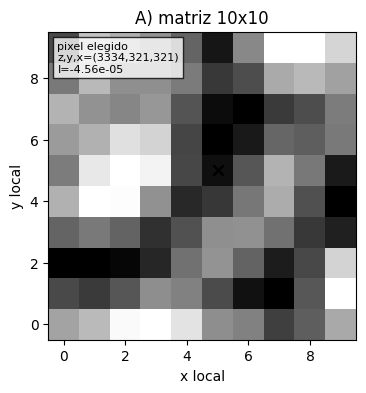

In [4]:
plot_a_patch(
    matrix10, local_y, local_x,
    (z_selected, y_selected, x_selected), selected_value,
    FIGURES_DIR / "A_matrix_10x10_gray.png",
    "A) matriz 10x10",
)


## B) La misma matriz con valores

La imagen B usa exactamente los mismos datos que A, pero escribe la intensidad float de cada celda.


Figura guardada: /home/willy/sdc2/demo/paso1/figures/00_tensor_pixel/B_matrix_10x10_values.png


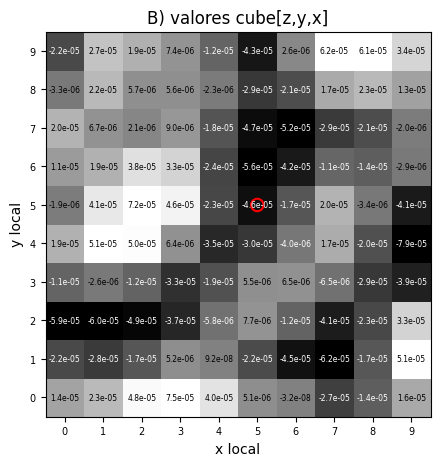

,x=316,x=317,x=318,x=319,x=320,x=321,x=322,x=323,x=324,x=325
y=316,1.362e-05,2.288e-05,4.844e-05,7.521e-05,3.984e-05,5.064e-06,-3.234e-08,-2.660e-05,-1.388e-05,1.586e-05
y=317,-2.224e-05,-2.838e-05,-1.726e-05,5.201e-06,9.206e-08,-2.179e-05,-4.493e-05,-6.215e-05,-1.675e-05,5.072e-05
y=318,-5.889e-05,-5.960e-05,-4.935e-05,-3.652e-05,-5.835e-06,7.707e-06,-1.203e-05,-4.059e-05,-2.284e-05,3.323e-05
y=319,-1.144e-05,-2.635e-06,-1.221e-05,-3.261e-05,-1.887e-05,5.489e-06,6.497e-06,-6.495e-06,-2.925e-05,-3.854e-05
y=320,1.934e-05,5.133e-05,4.993e-05,6.421e-06,-3.523e-05,-2.986e-05,-4.021e-06,1.718e-05,-1.961e-05,-7.867e-05
y=321,-1.877e-06,4.144e-05,7.221e-05,4.628e-05,-2.330e-05,-4.561e-05,-1.741e-05,2.033e-05,-3.405e-06,-4.116e-05
y=322,1.050e-05,1.939e-05,3.803e-05,3.329e-05,-2.408e-05,-5.567e-05,-4.175e-05,-1.064e-05,-1.411e-05,-2.930e-06
y=323,2.023e-05,6.717e-06,2.074e-06,8.991e-06,-1.797e-05,-4.686e-05,-5.173e-05,-2.852e-05,-2.095e-05,-2.035e-06
y=324,-3.272e-06,2.242e-05,5.707e-06,5.628e-06,-2.316e-06,-2.885e-05,-2.096e-05,1.652e-05,2.262e-05,1.283e-05
y=325,-2.207e-05,2.692e-05,1.900e-05,7.437e-06,-1.163e-05,-4.278e-05,2.631e-06,6.178e-05,6.112e-05,3.378e-05


Tabla guardada: /home/willy/sdc2/demo/paso1/tables/00_matrix_10x10_values.csv


In [5]:
plot_b_values(
    matrix10, local_y, local_x,
    FIGURES_DIR / "B_matrix_10x10_values.png",
    "B) valores cube[z,y,x]",
)

matrix_df = matrix_dataframe(matrix10, matrix_y0, matrix_x0)
display(matrix_df)
matrix_df.to_csv(TABLES_DIR / "00_matrix_10x10_values.csv")
print(f"Tabla guardada: {TABLES_DIR / '00_matrix_10x10_values.csv'}")


## C) Perfil z del píxel elegido

La curva C fija el mismo `(y_selected, x_selected)` marcado en A/B y recorre 10 canales de `z` alrededor de `z_selected`.


Figura guardada: /home/willy/sdc2/demo/paso1/figures/00_tensor_pixel/C_profile_z_10_channels.png


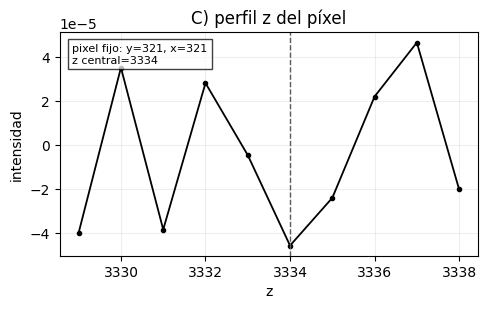

,z,y,x,intensity
0,3329,321,321,-0.000040
1,3330,321,321,0.000035
2,3331,321,321,-0.000038
3,3332,321,321,0.000028
4,3333,321,321,-0.000004
5,3334,321,321,-0.000046
6,3335,321,321,-0.000024
7,3336,321,321,0.000022
8,3337,321,321,0.000047
9,3338,321,321,-0.000020


Tabla guardada: /home/willy/sdc2/demo/paso1/tables/00_profile_z_10_channels.csv


In [6]:
plot_c_profile(
    z_values, profile10, z_selected, (y_selected, x_selected),
    FIGURES_DIR / "C_profile_z_10_channels.png",
    "C) perfil z del píxel",
)

profile_df = pd.DataFrame({"z": z_values, "y": y_selected, "x": x_selected, "intensity": profile10})
display(profile_df)
profile_df.to_csv(TABLES_DIR / "00_profile_z_10_channels.csv", index=False)
print(f"Tabla guardada: {TABLES_DIR / '00_profile_z_10_channels.csv'}")


## Resumen A+B+C

Esta figura es la que conviene usar para explicar la correspondencia completa: matriz, valores y recorrido espectral del mismo punto.


Figura guardada: /home/willy/sdc2/demo/paso1/figures/00_tensor_pixel/ABC_summary.png


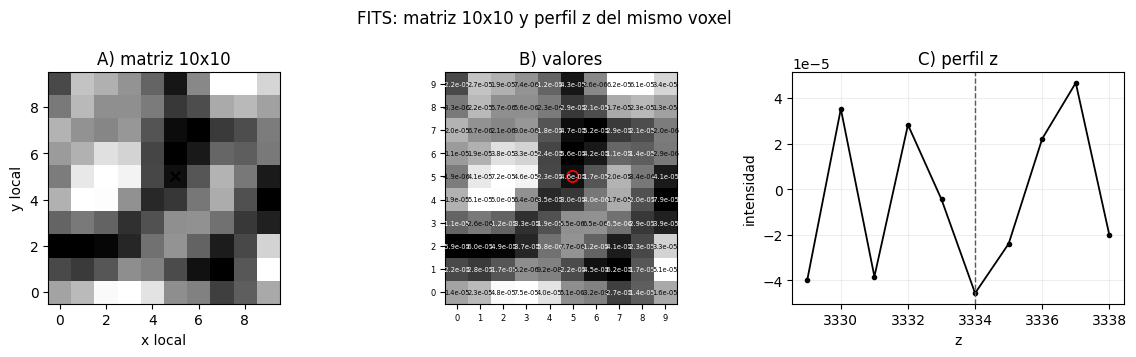

In [7]:
plot_summary(
    matrix10, local_y, local_x, z_values, profile10, z_selected,
    FIGURES_DIR / "ABC_summary.png",
    "FITS: matriz 10x10 y perfil z del mismo voxel",
)
hdul.close()
